# Original known-$R_p$ workflow: SciPy and Pyomo

This tutorial reuses the original LyoPRONTO vial, product, heat-transfer, pressure, and shelf-temperature case. The canonical computation lives in `examples.original_workflow_parity`; this notebook adds explanation and plots.

The legacy SciPy calculator integrates until the configured schedule ends or drying completes. The Pyomo model is a fixed-control validation replay on 26 backward-Euler intervals of 0.25 hr (6.5 hr total), with a terminal target of at least 95% dried. It is therefore a discretization comparison, not a replacement for event-terminated integration. The figures retain the original temperature, pressure/flux, and percent-dried diagnostics while overlaying the Pyomo replay.

In [1]:
from pathlib import Path
import sys
from time import perf_counter

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.original_workflow_parity import (
    KNOWN_RP_ENDPOINT_TOLERANCE_PP,
    build_known_rp_pyomo_model,
    pyomo_ipopt_status,
    run_known_rp_scipy,
    solve_known_rp_pyomo_model,
)

The seven legacy columns are time [hr], sublimation-front temperature [degC], vial-bottom temperature [degC], shelf temperature [degC], chamber pressure [mTorr], sublimation flux [kg/hr/m$^2$], and percent dried [0-100].

In [2]:
scipy_start = perf_counter()
scipy_output = run_known_rp_scipy(dt=0.25)
scipy_elapsed_s = perf_counter() - scipy_start
print(f"SciPy: {scipy_output.shape[0]} nodes, {scipy_output[-1, 0]:.2f} hr, {scipy_output[-1, 6]:.2f}% dried")
print(f"SciPy integration wall time: {scipy_elapsed_s:.4f} s")

SciPy: 27 nodes, 6.50 hr, 97.75% dried
SciPy integration wall time: 0.0273 s


In [3]:
pyomo_ready, pyomo_message = pyomo_ipopt_status()
print(pyomo_message)
pyomo_build_elapsed_s = None
pyomo_solve_elapsed_s = None
if pyomo_ready:
    pyomo_build_start = perf_counter()
    pyomo_model = build_known_rp_pyomo_model(scipy_output)
    pyomo_build_elapsed_s = perf_counter() - pyomo_build_start
    pyomo_solve_start = perf_counter()
    pyomo_result = solve_known_rp_pyomo_model(pyomo_model)
    pyomo_solve_elapsed_s = perf_counter() - pyomo_solve_start
else:
    pyomo_result = None
pyomo_output = pyomo_result.as_table() if pyomo_result is not None else None
if pyomo_result is not None:
    print(pyomo_result.message)
    print(f"Pyomo: {pyomo_output.shape[0]} nodes, {pyomo_output[-1, 0]:.2f} hr, {pyomo_output[-1, 6]:.2f}% dried")
    print(f"Pyomo model construction wall time: {pyomo_build_elapsed_s:.4f} s")
    print(f"Pyomo solver wall time: {pyomo_solve_elapsed_s:.4f} s")

Pyomo and IPOPT are available.


Pyomo trajectory solve reached optimal; maximum constraint violation 4.423e-08.
Pyomo: 27 nodes, 6.50 hr, 98.95% dried
Pyomo model construction wall time: 0.0083 s
Pyomo solver wall time: 0.3747 s


In [4]:
display(Markdown(
    f"On the default grid the accepted endpoint tolerance is "
    f"**{KNOWN_RP_ENDPOINT_TOLERANCE_PP:g} percentage points dried**. "
    "This tolerance records first-order backward-Euler discretization error; "
    "pressure and shelf-temperature controls are fixed to the same sampled ramp profiles. "
    "Reported wall times are single executions in the active environment, not benchmarks. "
    "SciPy integration, Pyomo model construction, and the IPOPT solve are timed separately "
    "because the two formulations do not have identical stopping rules or discretizations."
))

On the default grid the accepted endpoint tolerance is **1.5 percentage points dried**. This tolerance records first-order backward-Euler discretization error; pressure and shelf-temperature controls are fixed to the same sampled ramp profiles. Reported wall times are single executions in the active environment, not benchmarks. SciPy integration, Pyomo model construction, and the IPOPT solve are timed separately because the two formulations do not have identical stopping rules or discretizations.

In [5]:
if pyomo_output is not None:
    endpoint_error = abs(pyomo_output[-1, 6] - scipy_output[-1, 6])
    assert pyomo_output.shape[1] == scipy_output.shape[1] == 7
    assert endpoint_error <= KNOWN_RP_ENDPOINT_TOLERANCE_PP
    assert pyomo_build_elapsed_s >= 0.0
    assert pyomo_solve_elapsed_s >= 0.0
    print(f"Endpoint difference: {endpoint_error:.3f} percentage points dried")
assert scipy_elapsed_s >= 0.0

Endpoint difference: 1.197 percentage points dried


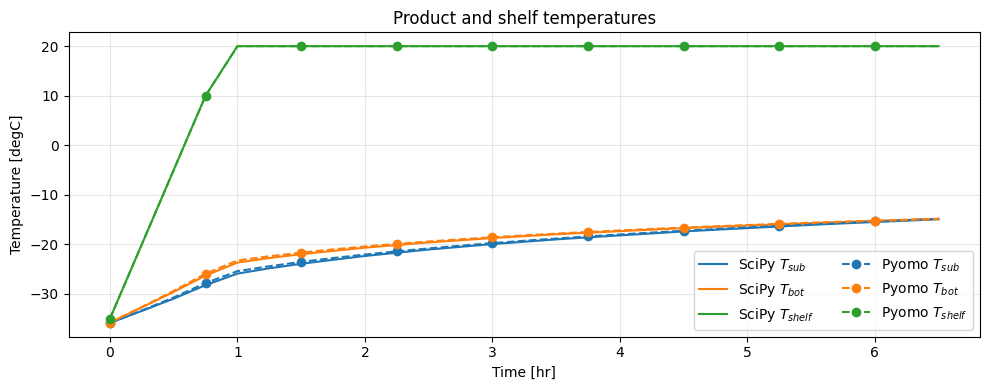

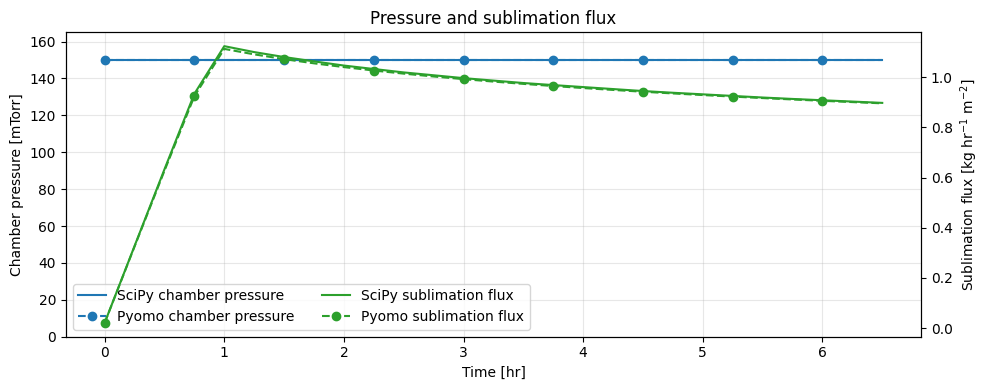

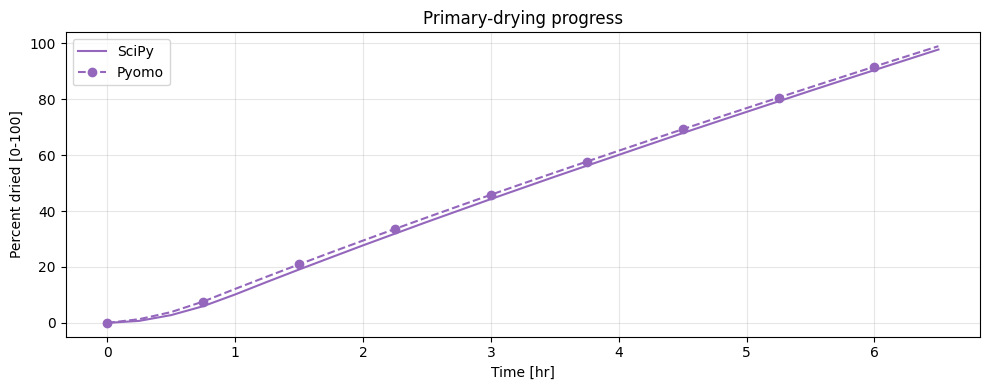

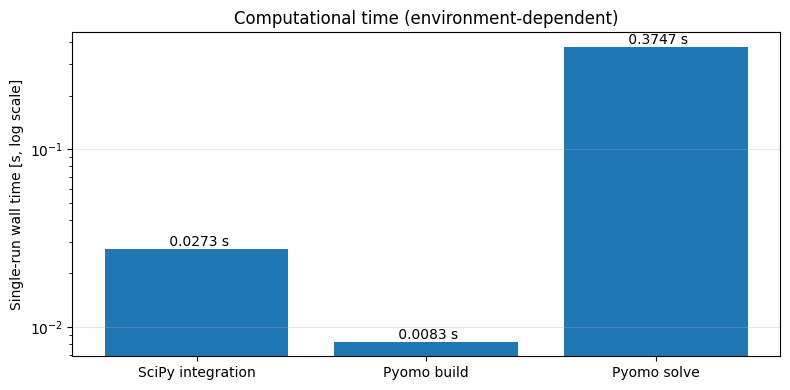

In [6]:
temperature_columns = ((1, r"$T_{sub}$", "C0"), (2, r"$T_{bot}$", "C1"), (3, r"$T_{shelf}$", "C2"))
fig_temperature, temperature_axis = plt.subplots(figsize=(10, 4))
for column, label, color in temperature_columns:
    temperature_axis.plot(scipy_output[:, 0], scipy_output[:, column], color=color, label=f"SciPy {label}")
if pyomo_output is not None:
    for column, label, color in temperature_columns:
        temperature_axis.plot(pyomo_output[:, 0], pyomo_output[:, column], "o--", markevery=3, color=color, label=f"Pyomo {label}")
temperature_axis.set(xlabel="Time [hr]", ylabel="Temperature [degC]", title="Product and shelf temperatures")
temperature_axis.grid(alpha=0.3)
temperature_axis.legend(ncols=2)
fig_temperature.tight_layout()

fig_transport, pressure_axis = plt.subplots(figsize=(10, 4))
flux_axis = pressure_axis.twinx()
pressure_axis.plot(scipy_output[:, 0], scipy_output[:, 4], color="C0", label="SciPy chamber pressure")
flux_axis.plot(scipy_output[:, 0], scipy_output[:, 5], color="C2", label="SciPy sublimation flux")
if pyomo_output is not None:
    pressure_axis.plot(pyomo_output[:, 0], pyomo_output[:, 4], "o--", markevery=3, color="C0", label="Pyomo chamber pressure")
    flux_axis.plot(pyomo_output[:, 0], pyomo_output[:, 5], "o--", markevery=3, color="C2", label="Pyomo sublimation flux")
pressure_max = max(scipy_output[:, 4].max(), pyomo_output[:, 4].max() if pyomo_output is not None else 0.0)
pressure_axis.set(xlabel="Time [hr]", ylabel="Chamber pressure [mTorr]", title="Pressure and sublimation flux")
pressure_axis.set_ylim(0.0, 1.1 * pressure_max)
flux_axis.set_ylabel(r"Sublimation flux [kg hr$^{-1}$ m$^{-2}$]")
pressure_axis.grid(alpha=0.3)
transport_lines = pressure_axis.lines + flux_axis.lines
pressure_axis.legend(transport_lines, [line.get_label() for line in transport_lines], ncols=2)
fig_transport.tight_layout()

fig_dried, dried_axis = plt.subplots(figsize=(10, 4))
dried_axis.plot(scipy_output[:, 0], scipy_output[:, 6], color="C4", label="SciPy")
if pyomo_output is not None:
    dried_axis.plot(pyomo_output[:, 0], pyomo_output[:, 6], "o--", markevery=3, color="C4", label="Pyomo")
dried_axis.set(xlabel="Time [hr]", ylabel="Percent dried [0-100]", title="Primary-drying progress")
dried_axis.grid(alpha=0.3)
dried_axis.legend()
fig_dried.tight_layout()

timing_labels = ["SciPy integration"]
timing_values = [scipy_elapsed_s]
if pyomo_build_elapsed_s is not None and pyomo_solve_elapsed_s is not None:
    timing_labels.extend(["Pyomo build", "Pyomo solve"])
    timing_values.extend([pyomo_build_elapsed_s, pyomo_solve_elapsed_s])
fig_timing, timing_axis = plt.subplots(figsize=(8, 4))
timing_axis.bar(timing_labels, timing_values)
timing_axis.set_yscale("log")
timing_axis.set(ylabel="Single-run wall time [s, log scale]", title="Computational time (environment-dependent)")
timing_axis.grid(axis="y", alpha=0.3)
for index, value in enumerate(timing_values):
    timing_axis.text(index, value, f" {value:.4f} s", ha="center", va="bottom")
fig_timing.tight_layout()